  STEP 5: Visualizations

  Charts → C:\Users\bhuvancw\OneDrive\Desktop\Data Science Projects\DA Projects\shopmart-ecommerce-analytics\data\processed\charts



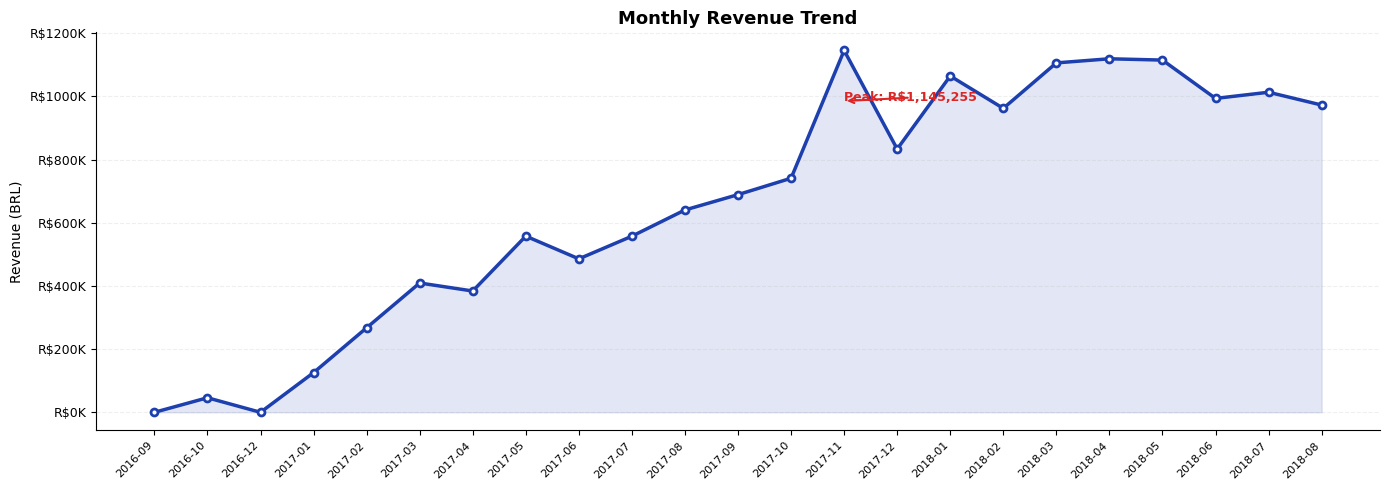

 ✅chart1_monthly_revenue.png


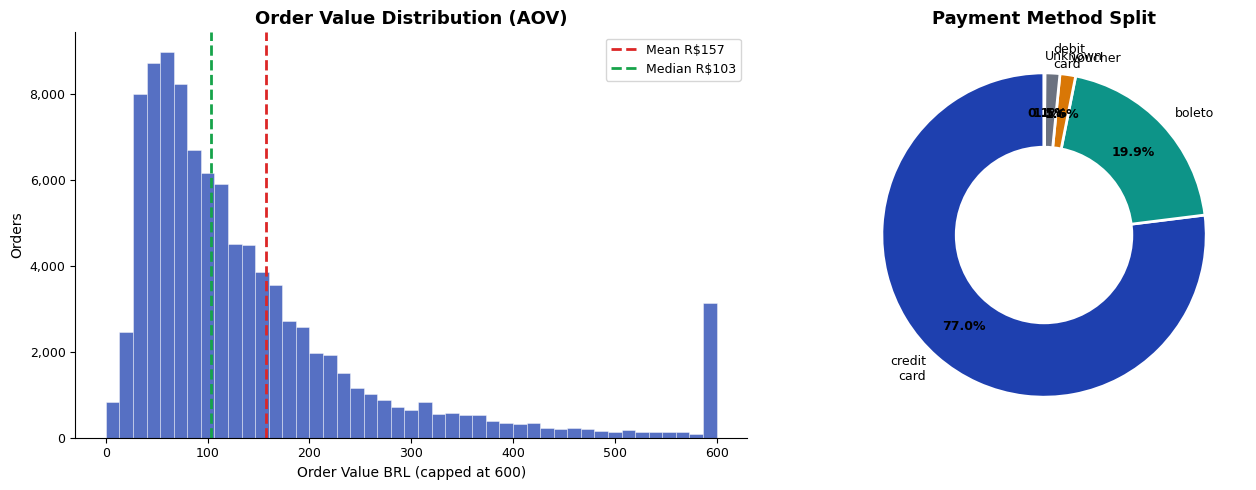

 ✅chart2_aov_payment.png


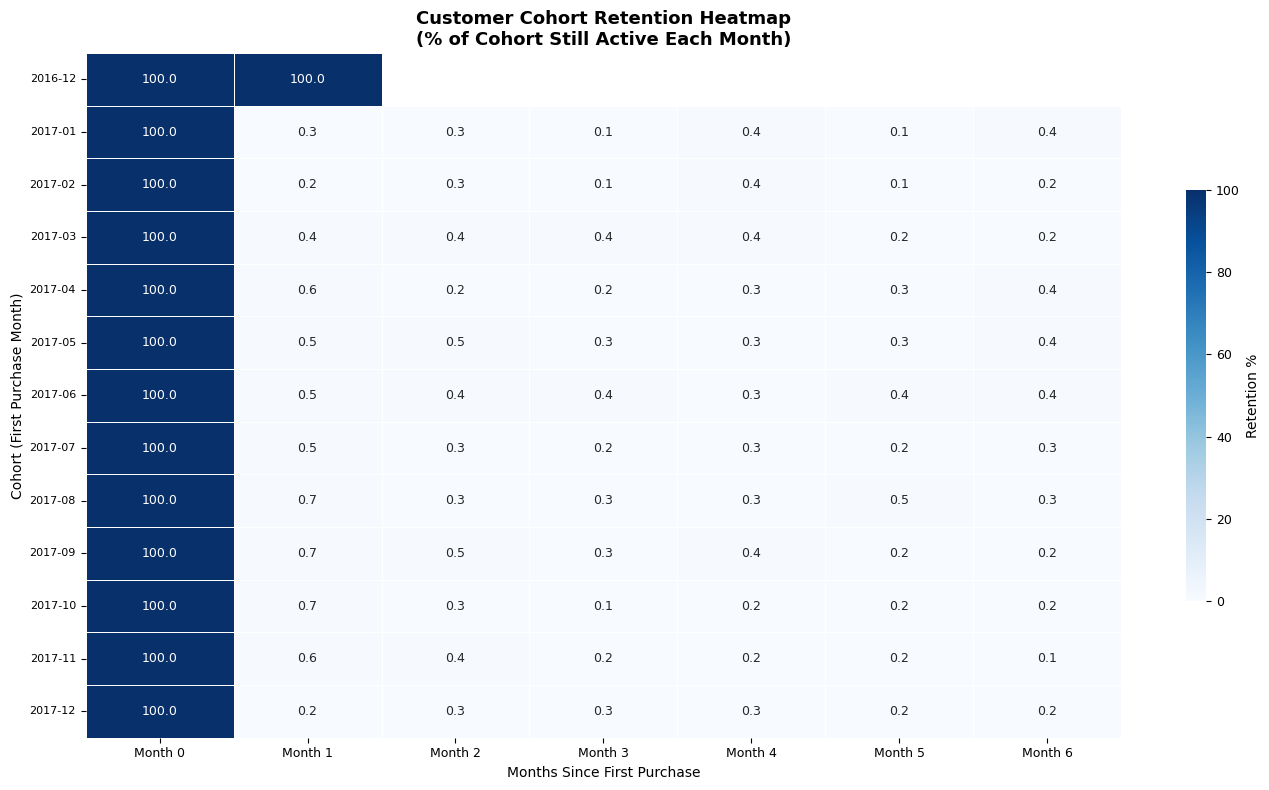

 ✅chart3_cohort_heatmap.png


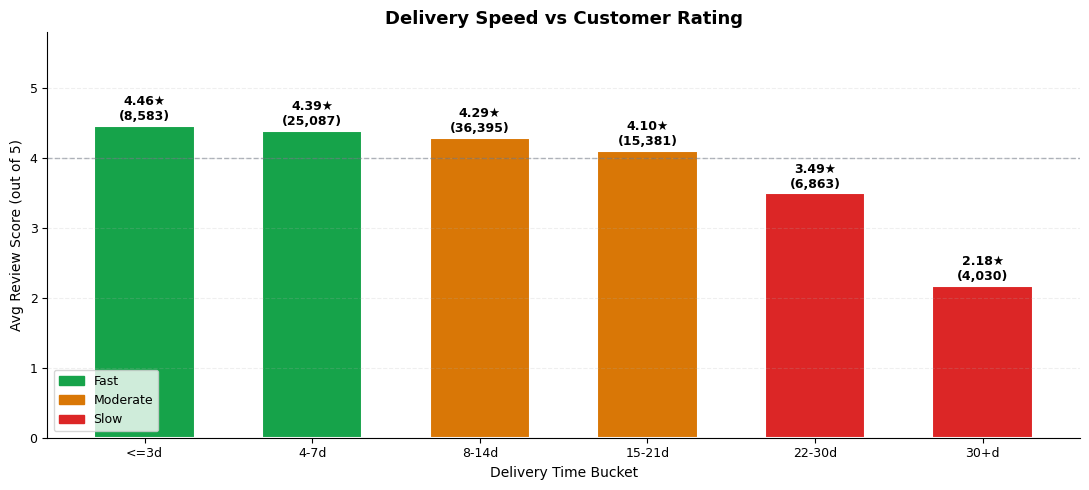

 ✅chart4_delivery_rating.png


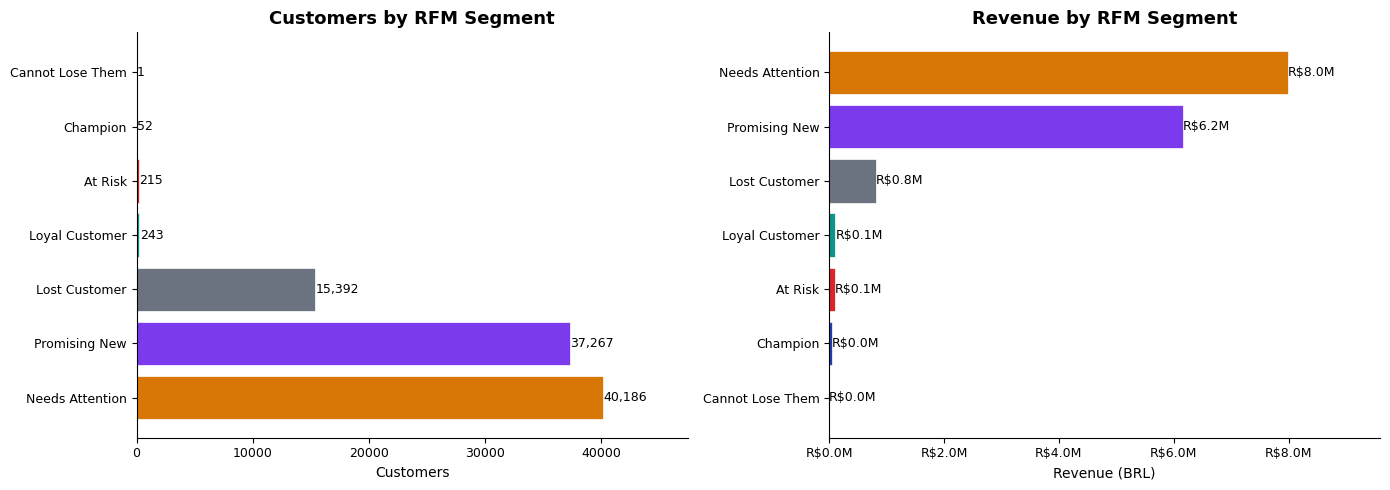

 ✅chart5_rfm_segments.png


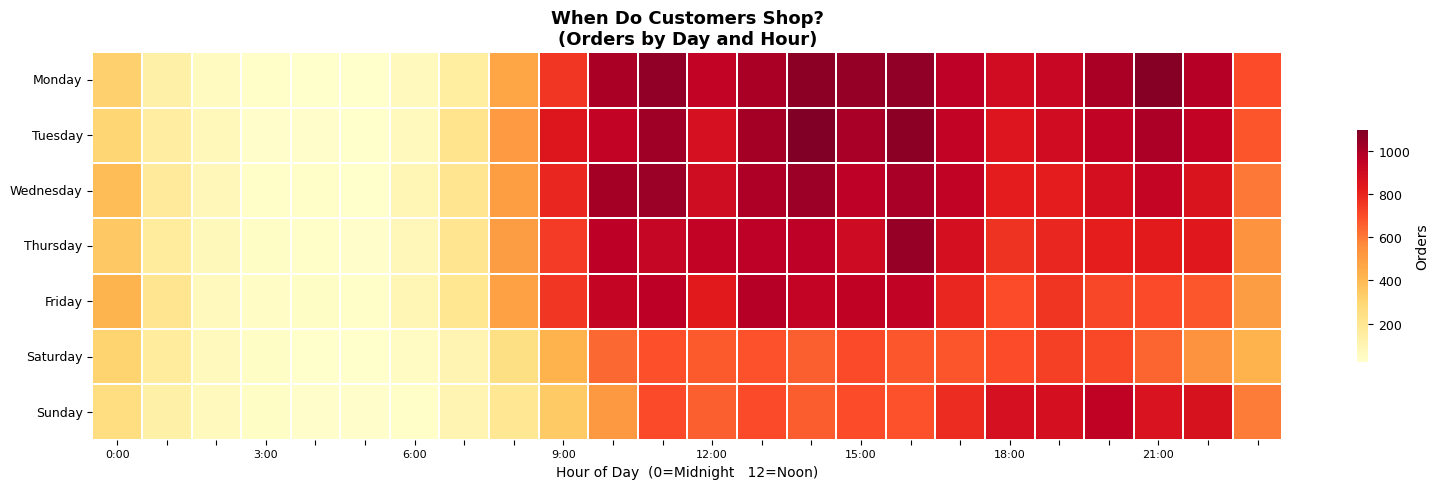

 ✅chart6_order_heatmap.png


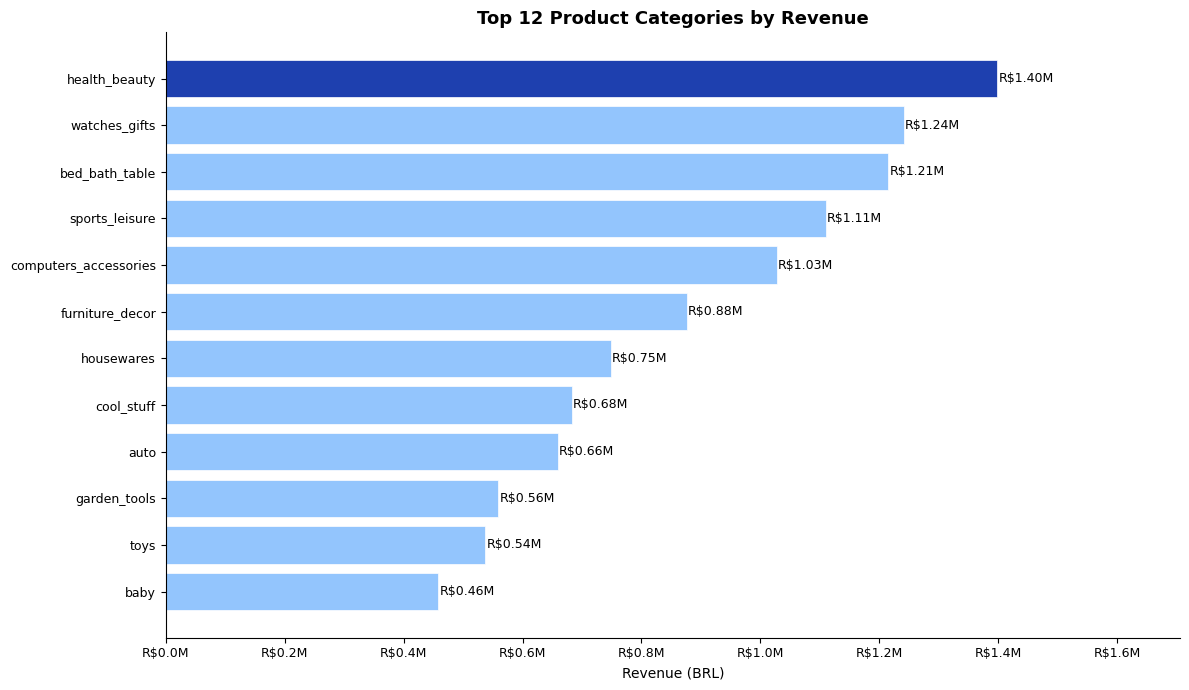

 ✅chart7_categories.png


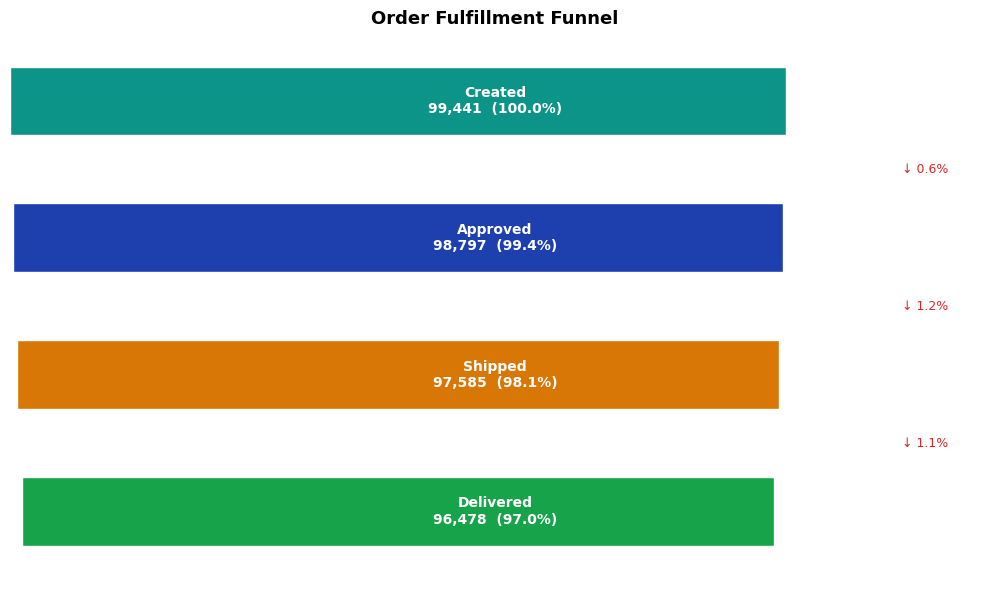

 ✅chart8_funnel.png

  All 8 charts saved to: C:\Users\bhuvancw\OneDrive\Desktop\Data Science Projects\DA Projects\shopmart-ecommerce-analytics\data\processed\charts


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import os
import sqlite3, os, warnings
warnings.filterwarnings('ignore')

proc = r"C:\Users\bhuvancw\OneDrive\Desktop\Data Science Projects\DA Projects\shopmart-ecommerce-analytics\data\processed"
charts = r"C:\Users\bhuvancw\OneDrive\Desktop\Data Science Projects\DA Projects\shopmart-ecommerce-analytics\data\processed\charts"
db = r"C:\Users\bhuvancw\OneDrive\Desktop\Data Science Projects\DA Projects\shopmart-ecommerce-analytics\data\shopmart.db"
os.makedirs(charts, exist_ok=True)

# ── Colors ────────────────────────────────────────────────────
BLUE  = "#1E40AF"
TEAL  = "#0D9488"
AMBER = "#D97706"
RED   = "#DC2626"
GREEN = "#16A34A"
GRAY  = "#6B7280"

plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.family":       "DejaVu Sans",
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "axes.labelsize":    10,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
})


def load_data():
    return pd.read_csv(os.path.join(proc, 'cleaned_ecommerce_data.csv'), parse_dates=['order_purchase_timestamp'])

def query_db(sql):
    """Run a SQL query and return result as DataFrame"""
    conn = sqlite3.connect(db)
    df = pd.read_sql_query(sql, conn)
    conn.close()
    return df

def save_chart(fig, name):
    """Save figure to charts folder and close it."""
    fig.savefig(os.path.join(charts,name), dpi = 150, bbox_inches = 'tight')
    plt.close(fig)
    print(f" ✅{name}")

def add_bar_label(ax, bars, fmt = "{:.0f}", offset = 0.02):
    """Add value labels above horizontal bars."""
    for bar in bars:
        w = bar.get_width()
        ax.text(w + w*offset,
                bar.get_y() + bar.get_width()/2,
                fmt.format(w),
                va = 'center', fontsize = 9)

# ── Charts ────────────────────────────────────────────────────

def chart1_monthly_revenue(df):
    """Line chart showing revenue trend with MoM peaks annotated."""
    fig, ax = plt.subplots(figsize = (14,5))
    monthly = (df.groupby(df['order_purchase_timestamp']
                          .dt.to_period("M"))
                          .agg(revenue = ('revenue', 'sum'))
                          .reset_index())
    
    monthly['label'] = monthly['order_purchase_timestamp'].astype(str)
    x = range(len(monthly))

    ax.fill_between(x, monthly['revenue'], alpha = 0.12, color = BLUE)
    ax.plot(x, monthly['revenue'], color = BLUE, lw = 2.5,
            marker = 'o', markersize = 5,
            markerfacecolor = 'white', markeredgewidth = 2)
    
    pk = monthly['revenue'].idxmax()
    ax.annotate(
        f'Peak: R${monthly.loc[pk, 'revenue']:,.0f}',
        xy = (pk, monthly.loc[pk, 'revenue']*0.86),
        arrowprops = dict(arrowstyle = '->', color = RED, lw = 1.5),
        fontsize = 9, color = RED, fontweight = 'bold'
    )

    ax.set_xticks(list(x))
    ax.set_xticklabels(monthly['label'], rotation = 45, ha = 'right', fontsize = 8)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v,_: f'R${v/1000:.0f}K'))
    ax.set_title("Monthly Revenue Trend")
    ax.set_ylabel("Revenue (BRL)")
    ax.grid(axis = 'y', alpha = 0.2, linestyle = '--')
    plt.tight_layout()
    plt.show()
    save_chart(fig, 'chart1_monthly_revenue.png')


def chart2_aov_payment(df):
    """Histogram of order values + donut for payment method split."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    cap = df["revenue"].clip(upper=600)
    axes[0].hist(cap, bins=45, color=BLUE, alpha=0.75,
                 edgecolor="white", lw=0.4)
    axes[0].axvline(df["revenue"].mean(),   color=RED,   ls="--", lw=2,
                    label=f"Mean R${df['revenue'].mean():.0f}")
    axes[0].axvline(df["revenue"].median(), color=GREEN, ls="--", lw=2,
                    label=f"Median R${df['revenue'].median():.0f}")
    axes[0].set_title("Order Value Distribution (AOV)")
    axes[0].set_xlabel("Order Value BRL (capped at 600)")
    axes[0].set_ylabel("Orders")
    axes[0].legend(fontsize=9)
    axes[0].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v,_: f"{v:,.0f}"))
    
    pc = df["payment_type"].value_counts()
    cols = [BLUE,TEAL,AMBER,GRAY,RED][:len(pc)]
    _, _, autotexts = axes[1].pie(
        pc, labels=[p.replace("_","\n") for p in pc.index],
        autopct="%1.1f%%", colors=cols, startangle=90,
        wedgeprops={"edgecolor":"white","linewidth":2},
        pctdistance=0.75)
    for at in autotexts:
        at.set_fontsize(9); at.set_fontweight("bold")
    axes[1].add_artist(plt.Circle((0,0),0.55,fc="white"))
    axes[1].set_title("Payment Method Split")

    plt.tight_layout()
    plt.show()
    save_chart(fig, "chart2_aov_payment.png")

def chart3_cohort_heatmap(df):
    """Cohort retention heatmap — showpiece chart for interviews."""
    fig, ax = plt.subplots(figsize=(14, 8))
    dc = df[["customer_unique_id","order_purchase_timestamp"]].copy()
    dc["order_month"]  = dc["order_purchase_timestamp"].dt.to_period("M")
    dc["cohort_month"] = (dc.groupby("customer_unique_id")
                            ["order_month"].transform("min"))
    dc["cohort_idx"]   = (dc["order_month"]
                           - dc["cohort_month"]).apply(lambda x: x.n)

    counts  = (dc.groupby(["cohort_month","cohort_idx"])
                 ["customer_unique_id"].nunique())
    pivot   = counts.unstack(fill_value=0)
    ret_pct = pivot.divide(pivot[0], axis=0).multiply(100).round(1)
    rplot   = ret_pct.iloc[2:15, :7]
    mask    = rplot.isnull() | (rplot == 0)

    sns.heatmap(
        rplot, annot=True, fmt=".1f", cmap="Blues", mask=mask,
        linewidths=0.5, linecolor="white", ax=ax,
        cbar_kws={"label":"Retention %","shrink":0.6},
        vmin=0, vmax=100, annot_kws={"fontsize":9})

    ax.set_title("Customer Cohort Retention Heatmap\n"
                 "(% of Cohort Still Active Each Month)")
    ax.set_xlabel("Months Since First Purchase")
    ax.set_ylabel("Cohort (First Purchase Month)")
    ax.set_xticklabels(
        [f"Month {i}" for i in rplot.columns], rotation=0, fontsize=9)
    ax.set_yticklabels(
        [str(c) for c in rplot.index], rotation=0, fontsize=8)
    plt.tight_layout()
    plt.show()
    save_chart(fig, "chart3_cohort_heatmap.png")

def chart4_delivery_rating(df):
    """Bar chart: delivery speed buckets vs average review score."""
    fig, ax = plt.subplots(figsize=(11, 5))
    dd = df[df["delivery_days"].notna() & df["review_score"].notna()].copy()
    dd["del_bkt"] = pd.cut(dd["delivery_days"],
        bins=[0,3,7,14,21,30,999],
        labels=["<=3d","4-7d","8-14d","15-21d","22-30d","30+d"])

    drv = (dd.groupby("del_bkt", observed=True)
             ["review_score"]
             .agg(mean="mean", count="count")
             .reset_index())

    cmap = {"<=3d":GREEN,"4-7d":GREEN,"8-14d":AMBER,
            "15-21d":AMBER,"22-30d":RED,"30+d":RED}
    bars = ax.bar(
        drv["del_bkt"].astype(str), drv["mean"],
        color=[cmap.get(str(b),BLUE) for b in drv["del_bkt"]],
        edgecolor="white", lw=1.5, width=0.6)

    for bar, (_, row) in zip(bars, drv.iterrows()):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.04,
                f"{row['mean']:.2f}★\n({int(row['count']):,})",
                ha="center", va="bottom", fontsize=9, fontweight="bold")
        
    ax.set_title("Delivery Speed vs Customer Rating")
    ax.set_xlabel("Delivery Time Bucket")
    ax.set_ylabel("Avg Review Score (out of 5)")
    ax.set_ylim(0, 5.8)
    ax.axhline(4.0, color=GRAY, ls="--", alpha=0.5, lw=1)
    ax.legend(handles=[
        mpatches.Patch(color=GREEN, label="Fast"),
        mpatches.Patch(color=AMBER, label="Moderate"),
        mpatches.Patch(color=RED,   label="Slow"),
    ], loc="lower left", fontsize=9)
    ax.grid(axis="y", alpha=0.2, ls="--")
    plt.tight_layout()
    plt.show()
    save_chart(fig, "chart4_delivery_rating.png")

def chart5_rfm_segments(df):
    """Side-by-side bars: customer count and revenue by RFM segment."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ref = df["order_purchase_timestamp"].max()

    rfm = df.groupby("customer_unique_id").agg(
        recency   = ("order_purchase_timestamp",
                     lambda x: (ref - x.max()).days),
        frequency = ("order_id","count"),
        monetary  = ("revenue","sum")
    ).reset_index()

    rfm["r"] = (6 - pd.qcut(rfm["recency"],  q=5, labels=[1,2,3,4,5],
                              duplicates="drop").astype(int))
    # For frequency, use custom bins to handle low unique values
    freq_bins = [0, 1, 2, 3, 5, rfm["frequency"].max() + 1]
    rfm["f"] = pd.cut(rfm["frequency"], bins=freq_bins, labels=[1,2,3,4,5], include_lowest=True).astype(int)
    rfm["m"] =      pd.qcut(rfm["monetary"],  q=5, labels=[1,2,3,4,5],
                              duplicates="drop").astype(int)
    
    def label_segment(row):
        """Assign RFM segment label based on R, F, M scores."""
        r,f,m = row["r"],row["f"],row["m"]
        if r>=4 and f>=4 and m>=4: return "Champion"
        if r>=3 and f>=3 and m>=3: return "Loyal Customer"
        if r>=4 and f<=2:          return "Promising New"
        if r<=2 and f>=3 and m>=3: return "At Risk"
        if r<=2 and f>=4:          return "Cannot Lose Them"
        if r<=2 and f<=2 and m<=2: return "Lost Customer"
        return "Needs Attention"

    rfm["segment"] = rfm.apply(label_segment, axis=1)

    seg_c = {
        "Champion":"#1E40AF","Loyal Customer":"#0D9488",
        "Promising New":"#7C3AED","Needs Attention":"#D97706",
        "At Risk":"#DC2626","Cannot Lose Them":"#9D174D",
        "Lost Customer":"#6B7280"
    }
    sc = rfm["segment"].value_counts()
    sr = rfm.groupby("segment")["monetary"].sum().sort_values()

    axes[0].barh(sc.index, sc.values,
                 color=[seg_c.get(s,BLUE) for s in sc.index],
                 edgecolor="white", lw=0.5)
    for bar, v in zip(axes[0].patches, sc.values):
        axes[0].text(bar.get_width()+20,
                     bar.get_y()+bar.get_height()/2,
                     f"{v:,}", va="center", fontsize=9)
    axes[0].set_title("Customers by RFM Segment")
    axes[0].set_xlabel("Customers")
    axes[0].set_xlim(0, sc.max()*1.18)

    axes[1].barh(sr.index, sr.values,
                 color=[seg_c.get(s,BLUE) for s in sr.index],
                 edgecolor="white", lw=0.5)
    for bar, v in zip(axes[1].patches, sr.values):
        axes[1].text(bar.get_width()+1000,
                     bar.get_y()+bar.get_height()/2,
                     f"R${v/1e6:.1f}M", va="center", fontsize=9)
    axes[1].set_title("Revenue by RFM Segment")
    axes[1].set_xlabel("Revenue (BRL)")
    axes[1].xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v,_: f"R${v/1e6:.1f}M"))
    axes[1].set_xlim(0, sr.max()*1.2)

    plt.tight_layout()
    plt.show()
    save_chart(fig, "chart5_rfm_segments.png")

def chart6_order_heatmap(df):
    """Day × Hour heatmap showing peak shopping windows."""
    fig, ax = plt.subplots(figsize=(16, 5))
    df["hour"]    = df["order_purchase_timestamp"].dt.hour
    df["weekday"] = df["order_purchase_timestamp"].dt.day_name()
    day_order     = ["Monday","Tuesday","Wednesday",
                     "Thursday","Friday","Saturday","Sunday"]
    heat = (df.groupby(["weekday","hour"])["order_id"]
              .count().reset_index())
    hp   = heat.pivot(index="weekday", columns="hour",
                      values="order_id")
    hp   = hp.reindex([d for d in day_order if d in hp.index])

    sns.heatmap(hp, cmap="YlOrRd", ax=ax,
                linewidths=0.2, linecolor="white",
                cbar_kws={"label":"Orders","shrink":0.6})
    ax.set_title("When Do Customers Shop?\n(Orders by Day and Hour)")
    ax.set_xlabel("Hour of Day  (0=Midnight   12=Noon)")
    ax.set_ylabel("")
    ax.set_xticklabels(
        [f"{h}:00" if h%3==0 else "" for h in range(24)],
        rotation=0, fontsize=8)
    plt.tight_layout()
    plt.show()
    save_chart(fig, "chart6_order_heatmap.png")


def chart7_categories(df):
    """Horizontal bar: top 12 product categories by revenue."""
    fig, ax = plt.subplots(figsize=(12, 7))
    cr = (df.groupby("category")["revenue"]
            .sum().sort_values(ascending=True).tail(12))
    colors = [BLUE if v==cr.max() else "#93C5FD" for v in cr.values]

    bars = ax.barh([str(c)[:35] for c in cr.index], cr.values,
                   color=colors, edgecolor="white", lw=0.5)
    for bar, v in zip(bars, cr.values):
        ax.text(bar.get_width()+2000,
                bar.get_y()+bar.get_height()/2,
                f"R${v/1e6:.2f}M", va="center", fontsize=9)

    ax.set_title("Top 12 Product Categories by Revenue")
    ax.set_xlabel("Revenue (BRL)")
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v,_: f"R${v/1e6:.1f}M"))
    ax.set_xlim(0, cr.max()*1.22)
    plt.tight_layout()
    plt.show()
    save_chart(fig, "chart7_categories.png")

def chart8_funnel():
    """Funnel chart from live SQLite data showing order drop-offs."""
    funnel = query_db("""
        SELECT
            COUNT(DISTINCT order_id)                          AS created,
            COUNT(DISTINCT CASE WHEN order_status!='canceled'
                  AND order_approved_at IS NOT NULL
                  THEN order_id END)                          AS approved,
            COUNT(DISTINCT CASE WHEN order_status IN
                  ('shipped','delivered') THEN order_id END)  AS shipped,
            COUNT(DISTINCT CASE WHEN order_status='delivered'
                  THEN order_id END)                          AS delivered
        FROM orders
    """)

    fig, ax = plt.subplots(figsize=(10, 6))
    stages  = ["Created","Approved","Shipped","Delivered"]
    counts  = [int(funnel[s.lower()].iloc[0]) for s in stages]
    colors  = [TEAL, BLUE, AMBER, GREEN]
    total   = counts[0]

    for i, (stage, count) in enumerate(zip(stages, counts)):
        w    = count/total * 0.8
        left = (0.8-w)/2
        ax.barh(i, w, left=left, height=0.5,
                color=colors[i], edgecolor="white", lw=1)
        pct = count/total*100
        ax.text(0.5, i,
                f"{stage}\n{count:,}  ({pct:.1f}%)",
                ha="center", va="center",
                fontsize=10, fontweight="bold", color="white")

    for i in range(len(counts)-1):
        drop = (counts[i]-counts[i+1])/counts[i]*100
        ax.text(0.92, i+0.5, f"↓ {drop:.1f}%",
                va="center", fontsize=9, color=RED)

    ax.set_xlim(0,1); ax.set_ylim(-0.5,3.5)
    ax.set_yticks([]); ax.set_xticks([])
    ax.invert_yaxis()
    ax.set_title("Order Fulfillment Funnel")
    for sp in ax.spines.values(): sp.set_visible(False)
    plt.tight_layout()
    plt.show()
    save_chart(fig, "chart8_funnel.png")

# ── MAIN ──────────────────────────────────────────────────────
if __name__ == "__main__":
    print("=" * 55)
    print("  STEP 5: Visualizations")
    print("=" * 55)
    print(f"\n  Charts → {charts}\n")

    df = load_data()

    chart1_monthly_revenue(df)
    chart2_aov_payment(df)
    chart3_cohort_heatmap(df)
    chart4_delivery_rating(df)
    chart5_rfm_segments(df)
    chart6_order_heatmap(df)
    chart7_categories(df)
    chart8_funnel()

    print(f"\n  All 8 charts saved to: {charts}")